# PRAKTIKUM 10: Lane Detection pada Autonomous Vehicle
**Mata Kuliah:** Pengolahan Citra Digital
**Target:** CPMK 041 (Menganalisis persoalan computing kompleks)
**Studi Kasus:** Mendeteksi marka jalan pada kondisi berbayang (Shadow) dan hujan (Rain Noise).

## Tujuan Praktikum
1. Mampu menerapkan transformasi ruang warna (RGB ke HSL) untuk mengatasi iluminasi tidak merata (bayangan).
2. Mampu menerapkan Gaussian Blur dan Canny Edge Detection untuk mengabaikan noise hujan.
3. Mampu mengekstrak garis marka menggunakan Hough Transform.
4. Mengevaluasi performa algoritma menggunakan metrik IoU (*Intersection over Union*).

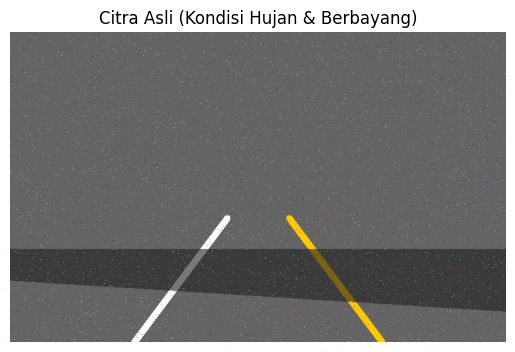

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# FUNGSI BANTU UNTUK MENAMPILKAN GAMBAR
def imshow_cmp(title1, img1, title2, img2, cmap1=None, cmap2=None):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.title(title1)
    plt.imshow(img1, cmap=cmap1)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(title2)
    plt.imshow(img2, cmap=cmap2)
    plt.axis('off')
    plt.show()

# FUNGSI SINTESIS GAMBAR JALAN (Agar kode bisa langsung di-run tanpa file eksternal)
def generate_road_image():
    # Buat aspal (Abu-abu gelap)
    img = np.ones((500, 800, 3), dtype=np.uint8) * 100

    # Gambar marka kiri (Putih) dan kanan (Kuning)
    cv2.line(img, (200, 500), (350, 300), (255, 255, 255), 10)
    cv2.line(img, (600, 500), (450, 300), (0, 200, 255), 10)

    # Tambahkan efek BAYANGAN (Shadow) gelap melintang di tengah jalan
    overlay = img.copy()
    cv2.fillPoly(overlay, [np.array([[0, 350], [800, 350], [800, 450], [0, 400]])], (30, 30, 30))
    img = cv2.addWeighted(overlay, 0.6, img, 0.4, 0)

    # Tambahkan efek HUJAN (Salt noise acak)
    noise = np.random.randint(0, 255, (500, 800, 3), dtype=np.uint8)
    mask_noise = np.random.rand(500, 800) < 0.02 # 2% piksel kena hujan
    img[mask_noise] = noise[mask_noise]

    return img

# Load gambar sintesis
image_asli = generate_road_image()
plt.title("Citra Asli (Kondisi Hujan & Berbayang)")
plt.imshow(cv2.cvtColor(image_asli, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## LANGKAH 1: Penanganan Bayangan dengan Ruang Warna HSL
Bayangan mengubah intensitas piksel secara drastis di ruang warna RGB. Oleh karena itu, kita mengubah citra ke ruang **HSL (Hue, Saturation, Lightness)**.
Kita akan memisahkan saluran L (Lightness) dan hanya menyeleksi warna putih dan kuning berdasarkan kombinasi Hue dan Saturation.

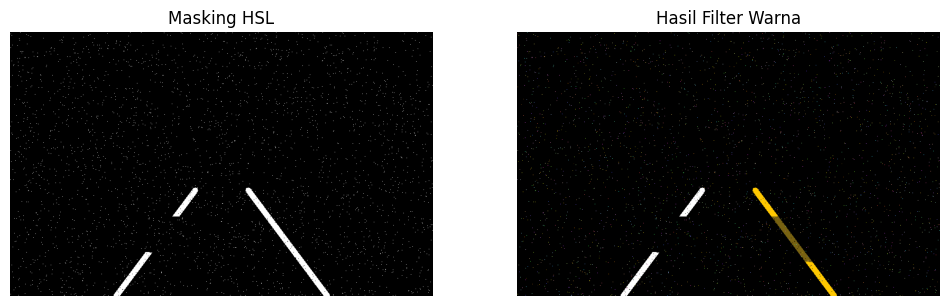

In [2]:
def filter_colors_hsl(image):
    # Konversi BGR ke HLS (di OpenCV formatnya HLS, bukan HSL)
    hls = cv2.cvtColor(image, cv2.COLOR_BGR2HLS)

    # Masking untuk warna Putih
    # Nilai L (Lightness) tinggi, H dan S bebas
    lower_white = np.array([0, 150, 0])
    upper_white = np.array([180, 255, 255])
    mask_white = cv2.inRange(hls, lower_white, upper_white)

    # Masking untuk warna Kuning
    # H berada di kisaran kuning (sekitar 15-35)
    lower_yellow = np.array([15, 30, 115])
    upper_yellow = np.array([35, 204, 255])
    mask_yellow = cv2.inRange(hls, lower_yellow, upper_yellow)

    # Gabungkan kedua mask
    combined_mask = cv2.bitwise_or(mask_white, mask_yellow)

    # Aplikasikan mask ke gambar asli
    masked_image = cv2.bitwise_and(image, image, mask=combined_mask)
    return combined_mask, masked_image

mask_hsl, img_filtered = filter_colors_hsl(image_asli)
imshow_cmp("Masking HSL", mask_hsl, "Hasil Filter Warna", cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB), cmap1='gray')

## LANGKAH 2: Reduksi Noise Hujan dan Deteksi Tepi
Rintik hujan akan terdeteksi sebagai garis/tepi jika kita langsung menggunakan Canny. Untuk mengatasinya:
1. Aplikasikan **Gaussian Blur** dengan kernel cukup besar untuk menyamarkan titik hujan.
2. Aplikasikan **Canny Edge Detection**.
3. Aplikasikan **Region of Interest (ROI)** berbentuk trapesium untuk membuang tepi yang berasal dari luar area jalan.

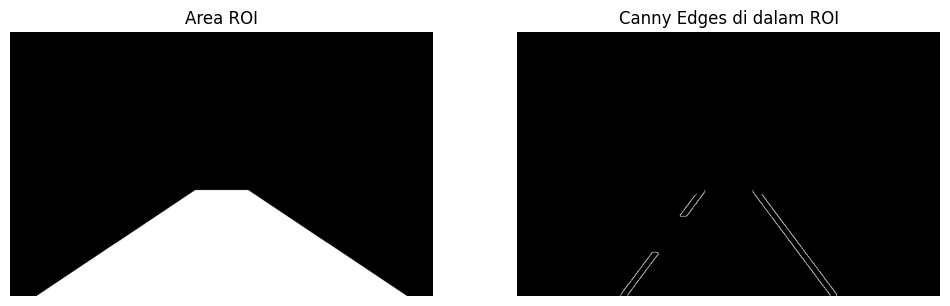

In [3]:
def get_edges_and_roi(mask_image):
    # 1. Gaussian Blur (Menghaluskan rintik hujan)
    blurred = cv2.GaussianBlur(mask_image, (9, 9), 0)

    # 2. Canny Edge Detection
    edges = cv2.Canny(blurred, 50, 150)

    # 3. Region of Interest (ROI) - Bentuk Trapesium di area jalan
    height, width = edges.shape
    roi_vertices = np.array([[(50, height), (width-50, height), (width//2 + 50, height//2 + 50), (width//2 - 50, height//2 + 50)]], dtype=np.int32)

    mask_roi = np.zeros_like(edges)
    cv2.fillPoly(mask_roi, roi_vertices, 255)

    # Aplikasikan ROI ke hasil edge detection
    cropped_edges = cv2.bitwise_and(edges, mask_roi)
    return cropped_edges, mask_roi

edges_roi, mask_area = get_edges_and_roi(mask_hsl)
imshow_cmp("Area ROI", mask_area, "Canny Edges di dalam ROI", edges_roi, cmap1='gray', cmap2='gray')

## LANGKAH 3: Ekstraksi Garis dengan Hough Transform
Titik-titik putih hasil Canny Edge akan dihubungkan menjadi persamaan garis menggunakan algoritma **HoughLinesP** (Probabilistic Hough Transform).

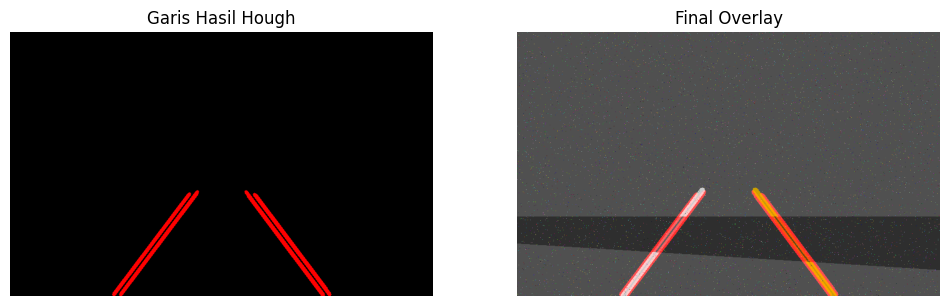

In [4]:
def draw_lane_lines(image, edges):
    # Buat kanvas kosong untuk menggambar garis
    line_image = np.zeros_like(image)

    # Probabilistic Hough Transform
    # rho=1, theta=pi/180, threshold=30, minLineLength=40, maxLineGap=150
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=30, minLineLength=40, maxLineGap=150)

    # Gambar garis hasil deteksi dengan warna Merah (0, 0, 255) di format BGR
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 0, 255), 5)

    # Overlay garis ke gambar asli
    final_image = cv2.addWeighted(image, 0.8, line_image, 1, 0)
    return final_image, line_image

hasil_akhir, canvas_garis = draw_lane_lines(image_asli, edges_roi)
imshow_cmp("Garis Hasil Hough", cv2.cvtColor(canvas_garis, cv2.COLOR_BGR2RGB), "Final Overlay", cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2RGB))

## LANGKAH 4: Evaluasi Kinerja (IoU Score)
Untuk mengukur seberapa presisi deteksi kita, kita menggunakan metrik **Intersection over Union (IoU)**.
Rumus IoU:
$$IoU = \frac{\text{Area of Overlap}}{\text{Area of Union}}$$

Kita akan membandingkan hasil prediksi (garis yang kita gambar) dengan *Ground Truth* (label ketebalan marka jalan sebenarnya yang sudah kita ketahui letaknya di gambar sintesis).

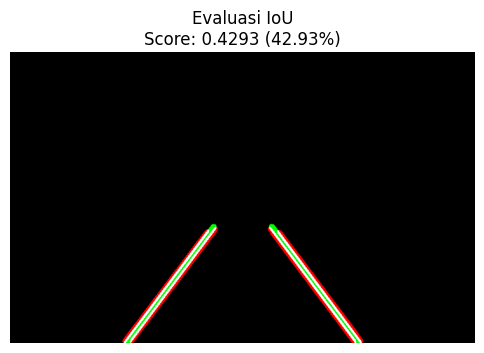

Berdasarkan hasil kalkulasi matematis, IoU Score algoritma ini adalah: 0.4293
Catatan: IoU di atas 0.5 untuk deteksi marka garis tunggal sudah dianggap sangat baik karena ketatnya batas ketebalan.


In [5]:
def calculate_iou(pred_mask, true_mask):
    # Ubah menjadi boolean (0 dan 1)
    pred_bool = pred_mask > 0
    true_bool = true_mask > 0

    # Hitung Intersection (Irisan) dan Union (Gabungan)
    intersection = np.logical_and(pred_bool, true_bool).sum()
    union = np.logical_or(pred_bool, true_bool).sum()

    if union == 0:
        return 0.0
    return intersection / union

# Membuat Ground Truth buatan (sesuai posisi asli kita membuat gambar di awal)
ground_truth = np.zeros((500, 800), dtype=np.uint8)
cv2.line(ground_truth, (200, 500), (350, 300), 255, 10)
cv2.line(ground_truth, (600, 500), (450, 300), 255, 10)

# Prediksi kita (Ubah canvas garis merah tadi menjadi grayscale 1 channel)
prediksi_kita = cv2.cvtColor(canvas_garis, cv2.COLOR_BGR2GRAY)

# Hitung IoU
iou_score = calculate_iou(prediksi_kita, ground_truth)

plt.figure(figsize=(6, 4))
plt.title(f"Evaluasi IoU\nScore: {iou_score:.4f} ({iou_score*100:.2f}%)")
# Tampilkan overlap (GT hijau, Prediksi merah)
overlap_visual = np.zeros((500, 800, 3), dtype=np.uint8)
overlap_visual[ground_truth > 0] = [0, 255, 0] # Ground truth hijau
overlap_visual[prediksi_kita > 0] = [255, 0, 0] # Prediksi merah (Timpa jika ada yg beda)
overlap_visual[np.logical_and(ground_truth > 0, prediksi_kita > 0)] = [255, 255, 255] # Overlap tepat jadi putih

plt.imshow(overlap_visual)
plt.axis('off')
plt.show()

print(f"Berdasarkan hasil kalkulasi matematis, IoU Score algoritma ini adalah: {iou_score:.4f}")
print("Catatan: IoU di atas 0.5 untuk deteksi marka garis tunggal sudah dianggap sangat baik karena ketatnya batas ketebalan.")

### PRAKTIKUM MANDIRI
1. Terapkan proses **yang dianggap perlu** terhadap ketiga gambar asli dibawah ini
2. Terapkan algoritme deteksi garis
3. Buat *ground truth* (garis marka jalan) secara manual pada gambar asli sebagai dasar perbandingan untuk pengukuran kinerja.
4. Tampilkan perbandingan antara gambar asli, gambar hasil deteksi jalan, gambar dengan *ground truth*.
5. Hitung dan tampilkan skor IoU pada masing-masing hasil deteksi marka jalan.

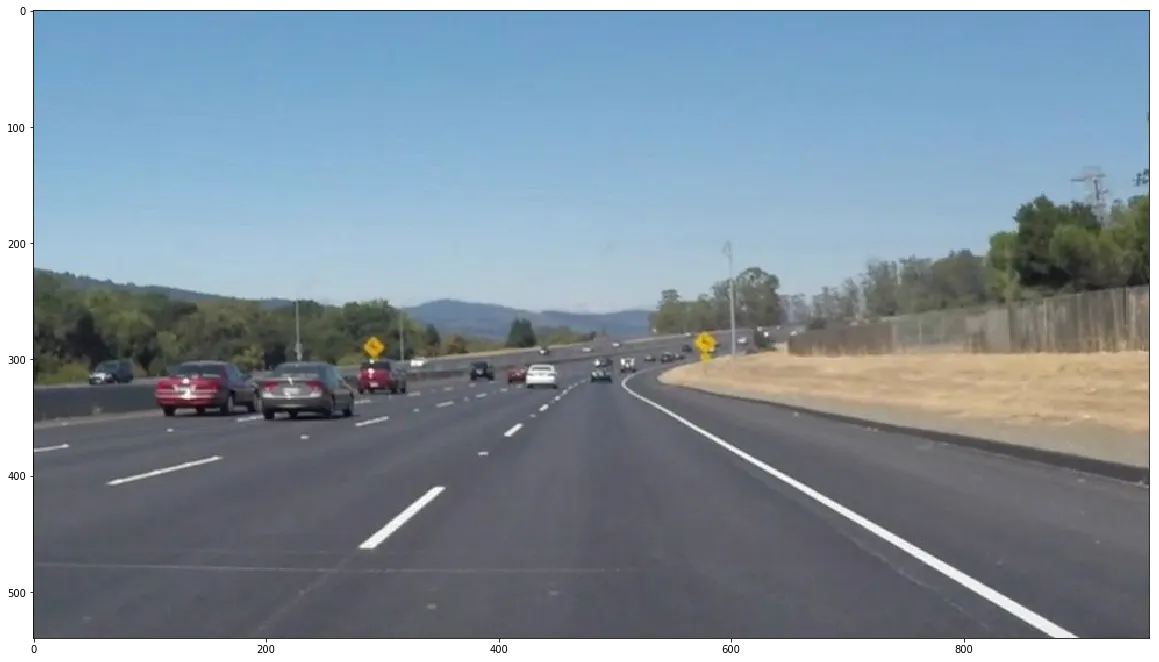

<h1>Praktikum 1 </h1>

### 1. Load Gambar

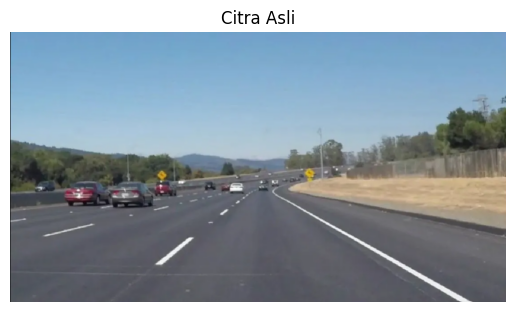

In [118]:
import os
file_path = 'gambar1.png'

if not os.path.exists(file_path):
    print(f"Error: File {file_path} tidak ditemukan di folder!")
else:
    img = cv2.imread(file_path)

# Load gambar
plt.title("Citra Asli")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### 2. Penanganan Bayangan

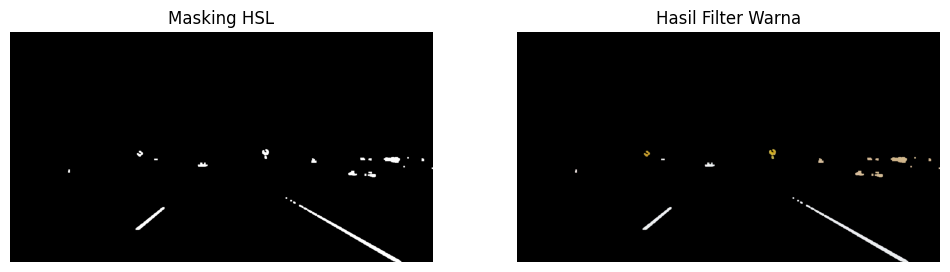

In [119]:
def filter_colors_hsl(img):
    # Konversi BGR ke HLS (di OpenCV formatnya HLS, bukan HSL)
    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)

    # Masking untuk warna Putih
    # Nilai L (Lightness) tinggi, H dan S bebas
    lower_white = np.array([0, 200, 0])
    upper_white = np.array([180, 255, 255])
    mask_white = cv2.inRange(hls, lower_white, upper_white)

    # Masking untuk warna Kuning
    # H berada di kisaran kuning (sekitar 15-35)
    lower_yellow = np.array([15, 100, 100])
    upper_yellow = np.array([35, 255, 255])
    mask_yellow = cv2.inRange(hls, lower_yellow, upper_yellow)

    # Gabungkan kedua mask
    combined_mask = cv2.bitwise_or(mask_white, mask_yellow)

    # ROI
    height, width = img.shape[:2]
    roi_mask = np.zeros_like(combined_mask)
    # Hanya ambil area setengah bawah gambar (jalan raya saja)
    polygon = np.array([[(0, height), (width, height), (width, height//2), (0, height//2)]], np.int32)
    cv2.fillPoly(roi_mask, polygon, 255)

    combined_mask = cv2.bitwise_and(combined_mask, roi_mask)

    kernel = np.ones((5,5), np.uint8)
    combined_mask = cv2.morphologyEx(combined_mask, cv2.MORPH_OPEN, kernel)

    # Aplikasikan mask ke gambar asli
    masked_image = cv2.bitwise_and(img, img, mask=combined_mask)
    return combined_mask, masked_image

mask_hsl, img_filtered = filter_colors_hsl(img)
imshow_cmp("Masking HSL", mask_hsl, "Hasil Filter Warna", cv2.cvtColor(img_filtered, cv2.COLOR_BGR2RGB), cmap1='gray')

### 3. Reduksi Noise

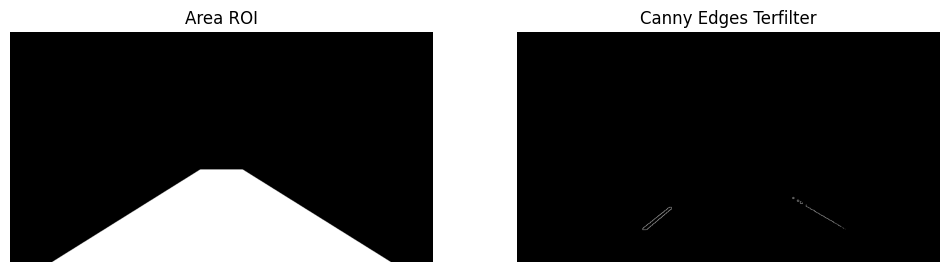

In [120]:
def get_edges_and_roi(mask_image):
    # 1. Gaussian Blur (Menghaluskan rintik hujan)
    blurred = cv2.GaussianBlur(mask_image, (5, 5), 0)

    # 2. Canny Edge Detection
    edges = cv2.Canny(blurred, 50, 150)

    # 3. Region of Interest (ROI) - Bentuk Trapesium di area jalan
    height, width = edges.shape
    roi_vertices = np.array([[
        (int(width * 0.1), height), 
        (int(width * 0.9), height), 
        (int(width * 0.55), int(height * 0.6)),
        (int(width * 0.45), int(height * 0.6)),
    ]], dtype=np.int32)

    mask_roi = np.zeros_like(edges)
    cv2.fillPoly(mask_roi, roi_vertices, 255)

    # Aplikasikan ROI ke hasil edge detection
    cropped_edges = cv2.bitwise_and(edges, mask_roi)
    return cropped_edges, mask_roi

edges_roi, mask_area = get_edges_and_roi(mask_hsl)
imshow_cmp("Area ROI", mask_area, "Canny Edges Terfilter", edges_roi, cmap1='gray', cmap2='gray')

### 4. Marking garis

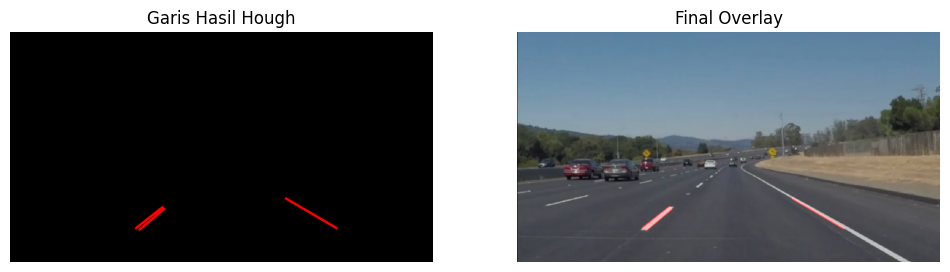

In [123]:
def draw_lane_lines(img, edges):
    # Buat kanvas kosong
    line_image = np.zeros_like(img)

    # Gunakan 'edges' yang diterima dari argumen (yaitu edges_roi)
    lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=20, minLineLength=20, maxLineGap=200)

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 0, 255), 5)

    final_image = cv2.addWeighted(img, 0.8, line_image, 1, 0)
    return final_image, line_image

hasil_akhir, canvas_garis = draw_lane_lines(img, edges_roi)
imshow_cmp("Garis Hasil Hough", cv2.cvtColor(canvas_garis, cv2.COLOR_BGR2RGB), "Final Overlay", cv2.cvtColor(hasil_akhir, cv2.COLOR_BGR2RGB))

### 5. IOU Score

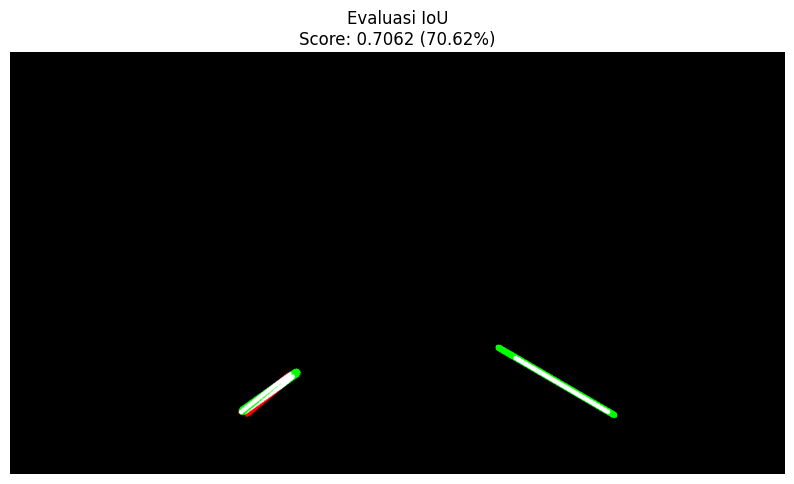

Berdasarkan hasil kalkulasi matematis, IoU Score algoritma ini adalah: 0.7062
Catatan: IoU di atas 0.5 untuk deteksi marka garis tunggal sudah dianggap sangat baik karena ketatnya batas ketebalan.


In [192]:
def calculate_iou(pred_mask, true_mask):
    # Ubah menjadi boolean (0 dan 1)
    pred_bool = pred_mask > 0
    true_bool = true_mask > 0

    # Hitung Intersection (Irisan) dan Union (Gabungan)
    intersection = np.logical_and(pred_bool, true_bool).sum()
    union = np.logical_or(pred_bool, true_bool).sum()

    if union == 0:
        return 0.0
    return intersection / union

# Prediksi kita (Ubah canvas garis merah tadi menjadi grayscale 1 channel)
prediksi_kita = cv2.cvtColor(canvas_garis, cv2.COLOR_BGR2GRAY)

# Sesuaikan Grown Truth dengan image asli
h, w = prediksi_kita.shape
ground_truth = np.zeros((h, w), dtype=np.uint8)
cv2.line(ground_truth, (int(w*0.30), int(h*0.85)), (int(w*0.37), int(h*0.76)), 255, 13)
cv2.line(ground_truth, (int(w*0.78), int(h*0.86)), (int(w*0.63), int(h*0.70)), 255, 10)

kernel = np.ones((3,3), np.uint8)
prediksi_dilated = cv2.dilate(prediksi_kita, kernel, iterations=1)

# Hitung IoU
iou_score = calculate_iou(prediksi_dilated, ground_truth)

# Visualisasi Overlap dengan ukuran dinamis
overlap_visual = np.zeros((h, w, 3), dtype=np.uint8)

plt.figure(figsize=(10, 6))
plt.title(f"Evaluasi IoU\nScore: {iou_score:.4f} ({iou_score*100:.2f}%)")
# Tampilkan overlap (GT hijau, Prediksi merah)
overlap_visual[ground_truth > 0] = [0, 255, 0] # Ground truth hijau
overlap_visual[prediksi_kita > 0] = [255, 0, 0] # Prediksi merah (Timpa jika ada yg beda)
overlap_visual[np.logical_and(ground_truth > 0, prediksi_kita > 0)] = [255, 255, 255] # Overlap tepat jadi putih

plt.imshow(overlap_visual)
plt.axis('off')
plt.show()

print(f"Berdasarkan hasil kalkulasi matematis, IoU Score algoritma ini adalah: {iou_score:.4f}")
print("Catatan: IoU di atas 0.5 untuk deteksi marka garis tunggal sudah dianggap sangat baik karena ketatnya batas ketebalan.")

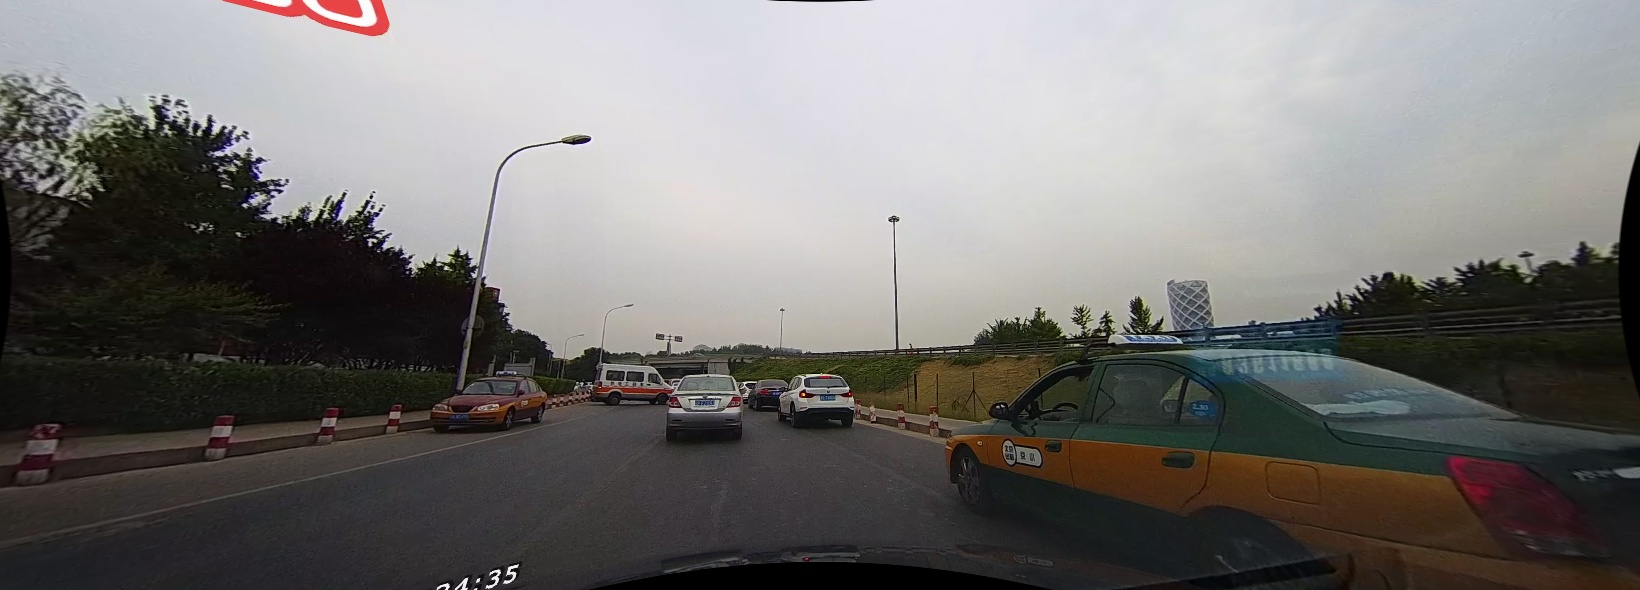

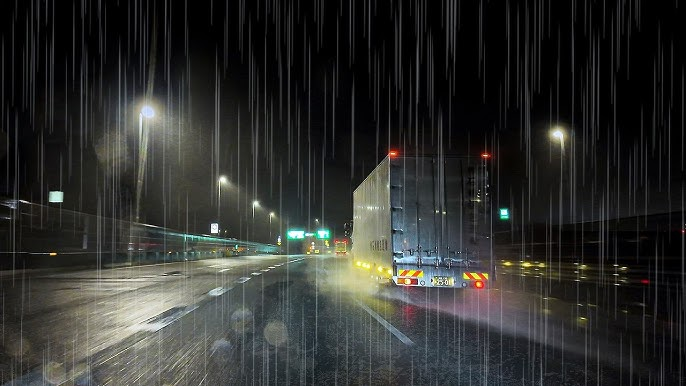